In [6]:
from google.colab import files
uploaded=files.upload()

Saving DataSet to DataSet (1)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df=pd.read_csv('DataSet (1)')
original_df=df.copy()

In [45]:
df.head()

,Order ID,Date,Status,ship-service-level,Category,Size,Qty,Amount,ship-state,ship-city,ship-postal-code,Year,Month,Day,Day of Week,Day Name,Total_Revenue
0,405-8078784-5731545,2022-04-30,Cancelled,Standard,Set,S,0,647.62,Maharashtra,Mumbai,400081.0,2022,4,30,5,Saturday,0.0
1,171-9198151-1101146,2022-04-30,Shipped - Delivered To Buyer,Standard,Kurta,3Xl,1,406.00,Karnataka,Bengaluru,560085.0,2022,4,30,5,Saturday,406.0
2,404-0687676-7273146,2022-04-30,Shipped,Expedited,Kurta,Xl,1,329.00,Maharashtra,Navi Mumbai,410210.0,2022,4,30,5,Saturday,329.0
3,403-9615377-8133951,2022-04-30,Cancelled,Standard,Western Dress,L,0,753.33,Pondicherry,Puducherry,605008.0,2022,4,30,5,Saturday,0.0
4,407-1069790-7240320,2022-04-30,Shipped,Expedited,Top,3Xl,1,574.00,Tamil Nadu,Chennai,600073.0,2022,4,30,5,Saturday,574.0


In [46]:
df=df[df['Status']=='Shipped - Delivered To Buyer']
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
df['Month_Name']=df['Date'].dt.month_name()


In [47]:
df.head()

,Order ID,Date,Status,ship-service-level,Category,Size,Qty,Amount,ship-state,ship-city,ship-postal-code,Year,Month,Day,Day of Week,Day Name,Total_Revenue,Month_Name
1,171-9198151-1101146,2022-04-30,Shipped - Delivered To Buyer,Standard,Kurta,3Xl,1,406.0,Karnataka,Bengaluru,560085.0,2022,4,30,5,Saturday,406.0,April
7,406-7807733-3785945,2022-04-30,Shipped - Delivered To Buyer,Standard,Kurta,S,1,399.0,Telangana,Hyderabad,500032.0,2022,4,30,5,Saturday,399.0,April
11,405-5513694-8146768,2022-04-30,Shipped - Delivered To Buyer,Standard,Kurta,Xs,1,399.0,Maharashtra,Amravati.,444606.0,2022,4,30,5,Saturday,399.0,April
13,408-1298370-1920302,2022-04-30,Shipped - Delivered To Buyer,Standard,Set,L,1,771.0,Maharashtra,Mumbai,400053.0,2022,4,30,5,Saturday,771.0,April
14,403-4965581-9520319,2022-04-30,Shipped - Delivered To Buyer,Standard,Kurta,6Xl,1,544.0,Andhra Pradesh,Guntakal,515801.0,2022,4,30,5,Saturday,544.0,April


KPI SECTION

In [32]:
total_revenue=df['Total_Revenue'].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 18720851.0


In [35]:
total_orders=df['Order ID'].nunique()
print("Total Orders:",total_orders)

Total Orders: 26559


In [36]:
total_quatity=df['Qty'].sum()
print("Total Quantity Sold:",total_quatity)

Total Quantity Sold: 28682


In [37]:
avg_order_value=total_revenue/total_orders
print("Average Order Value:",avg_order_value)

Average Order Value: 704.8778568470199


In [38]:
top_category=df.groupby('Category')['Total_Revenue'].sum().idxmax()
print("Top Performing Category:",top_category)

Top Performing Category: Set


CATEGORY ANALYSIS

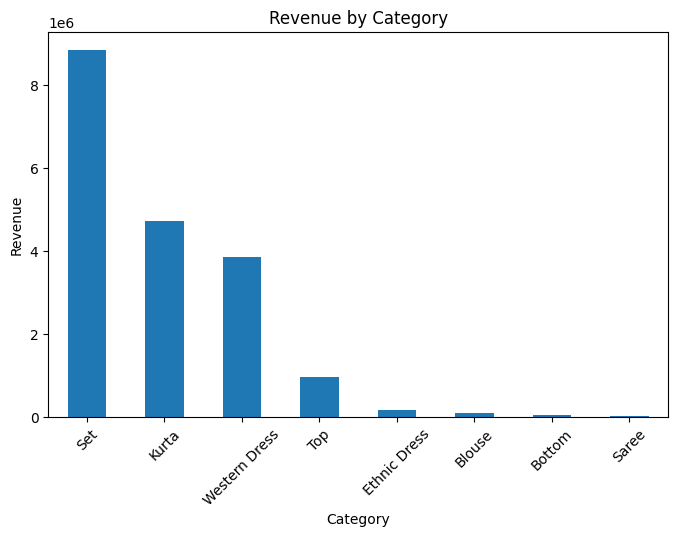

In [57]:
category_revenue=df.groupby('Category')['Total_Revenue'].sum().sort_values( ascending=False)
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

MONTHLY TREND

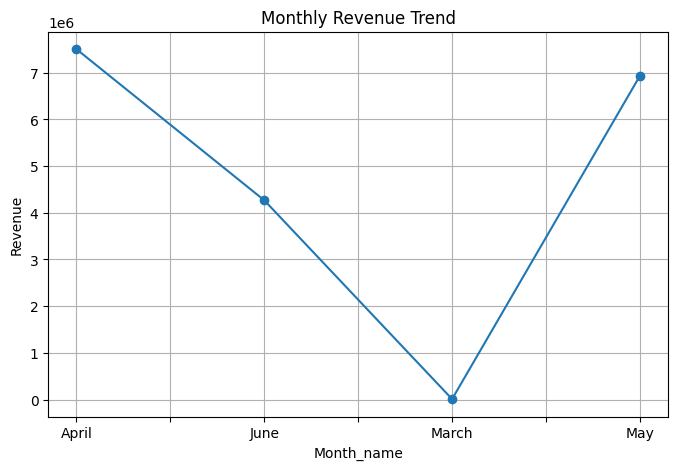

In [56]:
monthly_revenue=df.groupby('Month_Name')['Total_Revenue'].sum()
plt.figure(figsize=(8,5))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month_name')
plt.ylabel('Revenue')
plt.grid()
plt.show()

In [ ]:
STATUS ANALYSIS

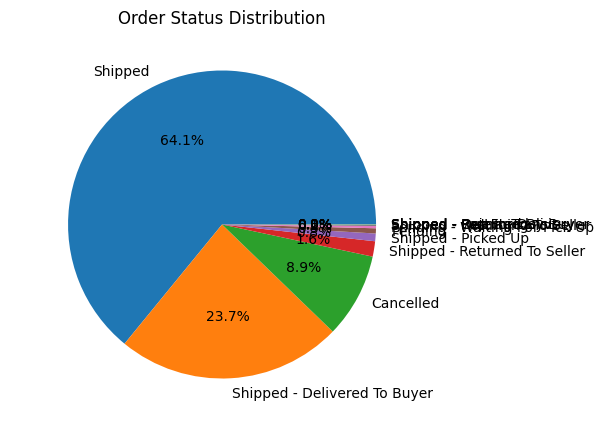

In [55]:
status_counts=original_df['Status'].value_counts()
plt.figure(figsize=(5,5))
status_counts.plot(kind='pie',autopct='%1.1f%%')
plt.title('Order Status Distribution')
plt.ylabel("     ")
plt.show()

STATE ANALYSIS

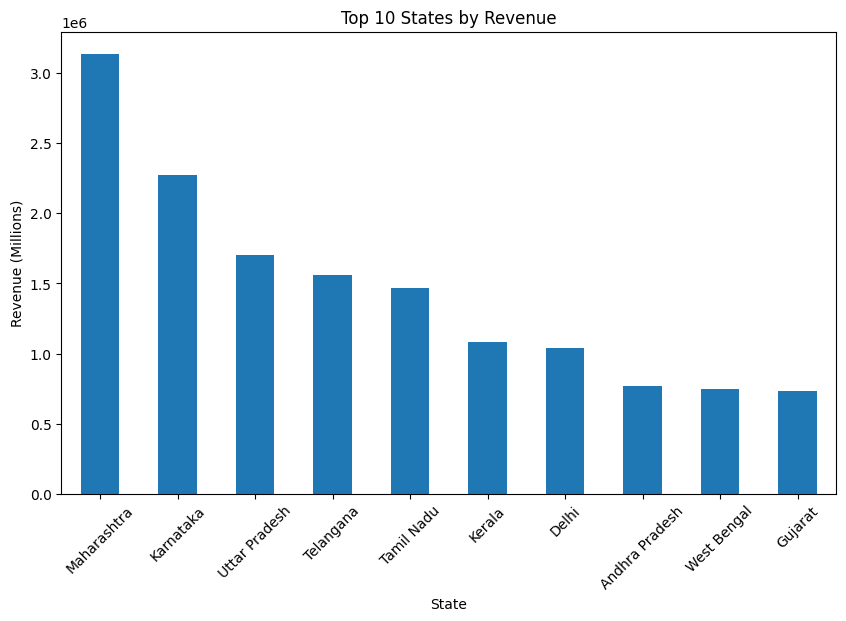

In [59]:
state_revenue=df.groupby('ship-state')['Total_Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
state_revenue.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)
plt.show()

INSIGHTS


*   The Total Revenue generated is high, indicating strong overall business performance.
*   The top performing category is "Set", contributing the highest share of revenue.


*   Monthly Trend shows fluctuations, with a peak in certain months indicating seasonal demand.
*   Majority of orders are successfully delivered, showing efficient order fulfillment.


*   Some categories and states contribute very less revenue, which can be targeted for improvement.
*   Average order value suggests customers are making moderate-value purchases.





